<a href="https://colab.research.google.com/github/Birnurdagli/Vize-Final/blob/main/Yapaysiniraglari_Birnur_Dagli.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn.datasets import load_breast_cancer
import pandas as pd


In [3]:
# 1.1 scikit-learn’den Veri Seti Yükleme
cancer_data = load_breast_cancer()


In [4]:
# 1.2 Veri Çerçevesi Oluşturma

X = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
y = pd.Series(cancer_data.target)

# İlk 5 satırı görüntüleme
print("###  Özellikler (X) - İlk 5 Satır ###")
print(X.head())

print("\n###  Hedef Değişken (y) - Dağılım ###")
print(y.value_counts())

###  Özellikler (X) - İlk 5 Satır ###
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst te

In [5]:
# Eksik değer kontrolü
missing_values = X.isnull().sum()

print("### Eksik Değer Kontrolü (Missing Values) ###")

if (missing_values > 0).any():
    print(missing_values[missing_values > 0])

else:
    print("Veri setinde **eksik değer (NaN/Null) bulunmamaktadır**.")

### Eksik Değer Kontrolü (Missing Values) ###
Veri setinde **eksik değer (NaN/Null) bulunmamaktadır**.


In [6]:
from scipy import stats
import numpy as np

print("\n### Aykırı Değer Kontrolü (Z-Score Yöntemi) ###")

Z = np.abs(stats.zscore(X))
outlier_mask = Z > 3
total_outliers = np.sum(outlier_mask)
outlier_counts_by_feature = np.sum(outlier_mask, axis=0)
outliers_df = pd.Series(outlier_counts_by_feature, index=X.columns)
outliers_present = outliers_df[outliers_df > 0]

print(f"Toplam {total_outliers} adet (Z-Score > 3 olan) aykırı veri noktası tespit edildi.")

if not outliers_present.empty:
    print(f"\nToplam {len(outliers_present)} farklı sütunda aykırı değer bulundu. İlk 5 Sütun:")
    print(outliers_present.sort_values(ascending=False).head(5))
else:
    print("Z-Score yöntemi ile (eşik 3) önemli bir aykırı değer tespit edilmedi.")


### Aykırı Değer Kontrolü (Z-Score Yöntemi) ###
Toplam 211 adet (Z-Score > 3 olan) aykırı veri noktası tespit edildi.

Toplam 29 farklı sütunda aykırı değer bulundu. İlk 5 Sütun:
compactness error          12
symmetry error             11
fractal dimension error    10
worst area                 10
worst compactness          10
dtype: int64


In [7]:
import pandas as pd
import numpy as np


print("###  Veri Tipi ve Dağılım İncelemesi ###")

print("\nSütun Veri Tipleri (Dtype Bilgisi):")
print(X.dtypes.head())
dtype_counts = X.dtypes.value_counts()
numeric_count = dtype_counts.get(np.dtype('float64'), 0) + dtype_counts.get(np.dtype('int64'), 0)
categorical_count = dtype_counts.get(np.dtype('object'), 0)

print("\nDeğişken Sayıları:")
print(f"Toplam Özellik Sayısı: {X.shape[1]}")
print(f"Sayısal (Float) Değişken Sayısı: **{numeric_count}**")
print(f"Kategorik (Object/String) Değişken Sayısı: **{categorical_count}**")

###  Veri Tipi ve Dağılım İncelemesi ###

Sütun Veri Tipleri (Dtype Bilgisi):
mean radius        float64
mean texture       float64
mean perimeter     float64
mean area          float64
mean smoothness    float64
dtype: object

Değişken Sayıları:
Toplam Özellik Sayısı: 30
Sayısal (Float) Değişken Sayısı: **30**
Kategorik (Object/String) Değişken Sayısı: **0**


**3. Keşifsel Veri Analizi (EDA)**


In [8]:


eda_stats = X.describe().loc[['mean', 'std', 'min', 'max', '25%', '50%', '75%']].T


eda_stats = eda_stats.rename(columns={
    'mean': 'Mean (Ortalama)',
    'std': 'Std (Standart Sapma)',
    'min': 'Min (Minimum)',
    'max': 'Max (Maksimum)',
    '25%': 'Q1',
    '50%': 'Median (Ortanca)',
    '75%': 'Q3'
})


eda_stats = eda_stats[['Mean (Ortalama)', 'Median (Ortanca)', 'Min (Minimum)', 'Max (Maksimum)', 'Std (Standart Sapma)', 'Q1', 'Q3']]


pd.set_option('display.max_rows', None)
print("###  Tüm Özelliklerin İstatistiksel Özetleri ###")
print(eda_stats)

###  Tüm Özelliklerin İstatistiksel Özetleri ###
                         Mean (Ortalama)  Median (Ortanca)  Min (Minimum)  \
mean radius                    14.127292         13.370000       6.981000   
mean texture                   19.289649         18.840000       9.710000   
mean perimeter                 91.969033         86.240000      43.790000   
mean area                     654.889104        551.100000     143.500000   
mean smoothness                 0.096360          0.095870       0.052630   
mean compactness                0.104341          0.092630       0.019380   
mean concavity                  0.088799          0.061540       0.000000   
mean concave points             0.048919          0.033500       0.000000   
mean symmetry                   0.181162          0.179200       0.106000   
mean fractal dimension          0.062798          0.061540       0.049960   
radius error                    0.405172          0.324200       0.111500   
texture error              

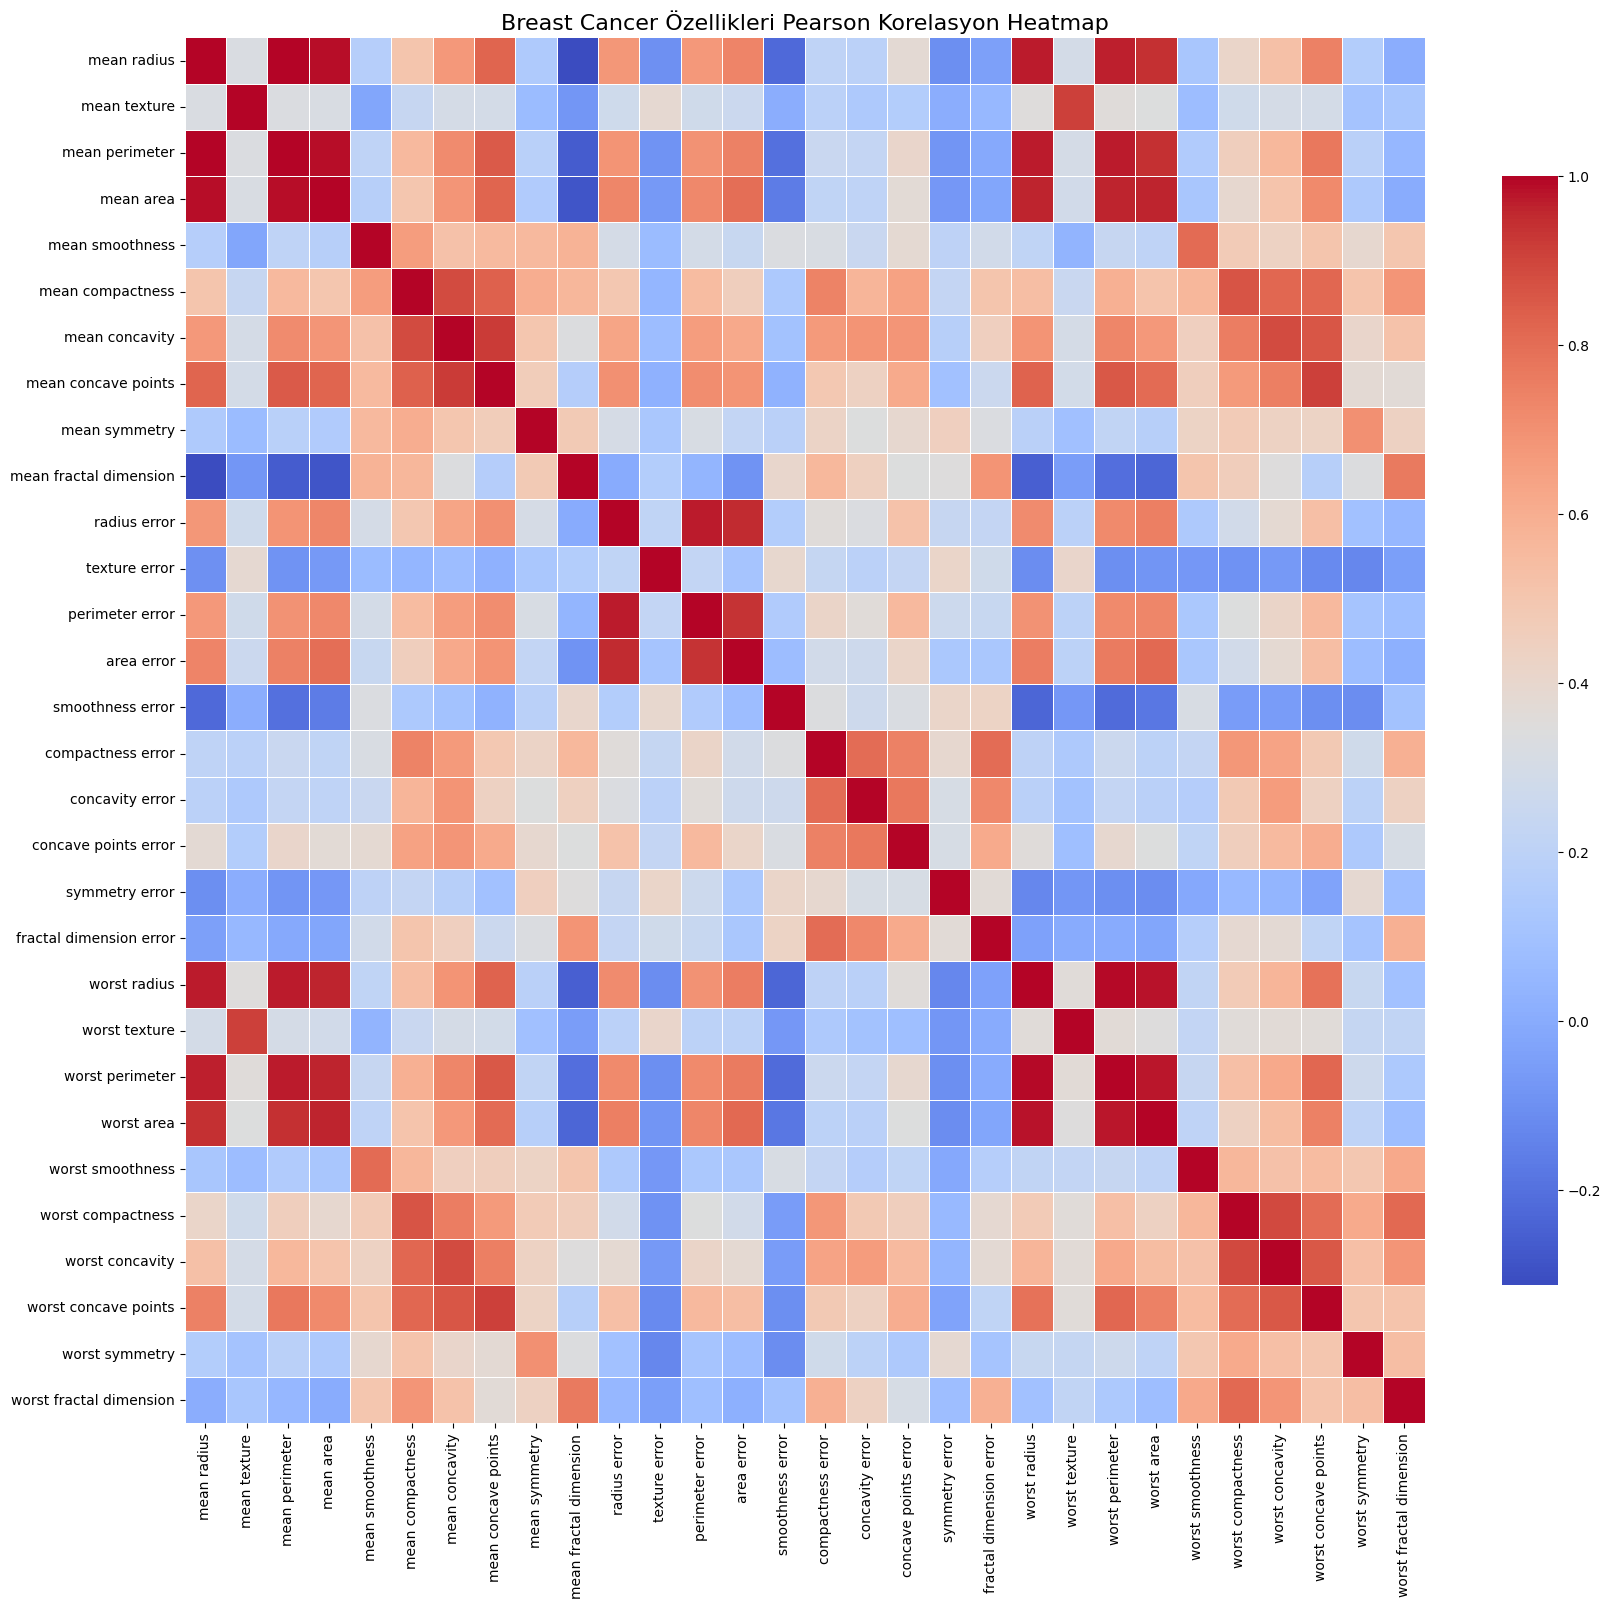


###  En Yüksek Korelasyonlu (Mutlak Değer) 3 Çift ###
mean perimeter   mean radius     0.997855
worst perimeter  worst radius    0.993708
mean area        mean radius     0.987357


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.datasets import load_breast_cancer
import pandas as pd

cancer_data = load_breast_cancer()
X = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)

# Pearson Korelasyon Matrisi
correlation_matrix = X.corr(method='pearson')


plt.figure(figsize=(20, 18))
sns.heatmap(
    correlation_matrix,
    annot=False,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5,
    cbar_kws={'shrink': .8}
)
plt.title('Breast Cancer Özellikleri Pearson Korelasyon Heatmap', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()


upper = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))


high_corr_pairs = upper.unstack().sort_values(ascending=False, key=abs).head(3)

print("\n###  En Yüksek Korelasyonlu (Mutlak Değer) 3 Çift ###")
print(high_corr_pairs.to_string())

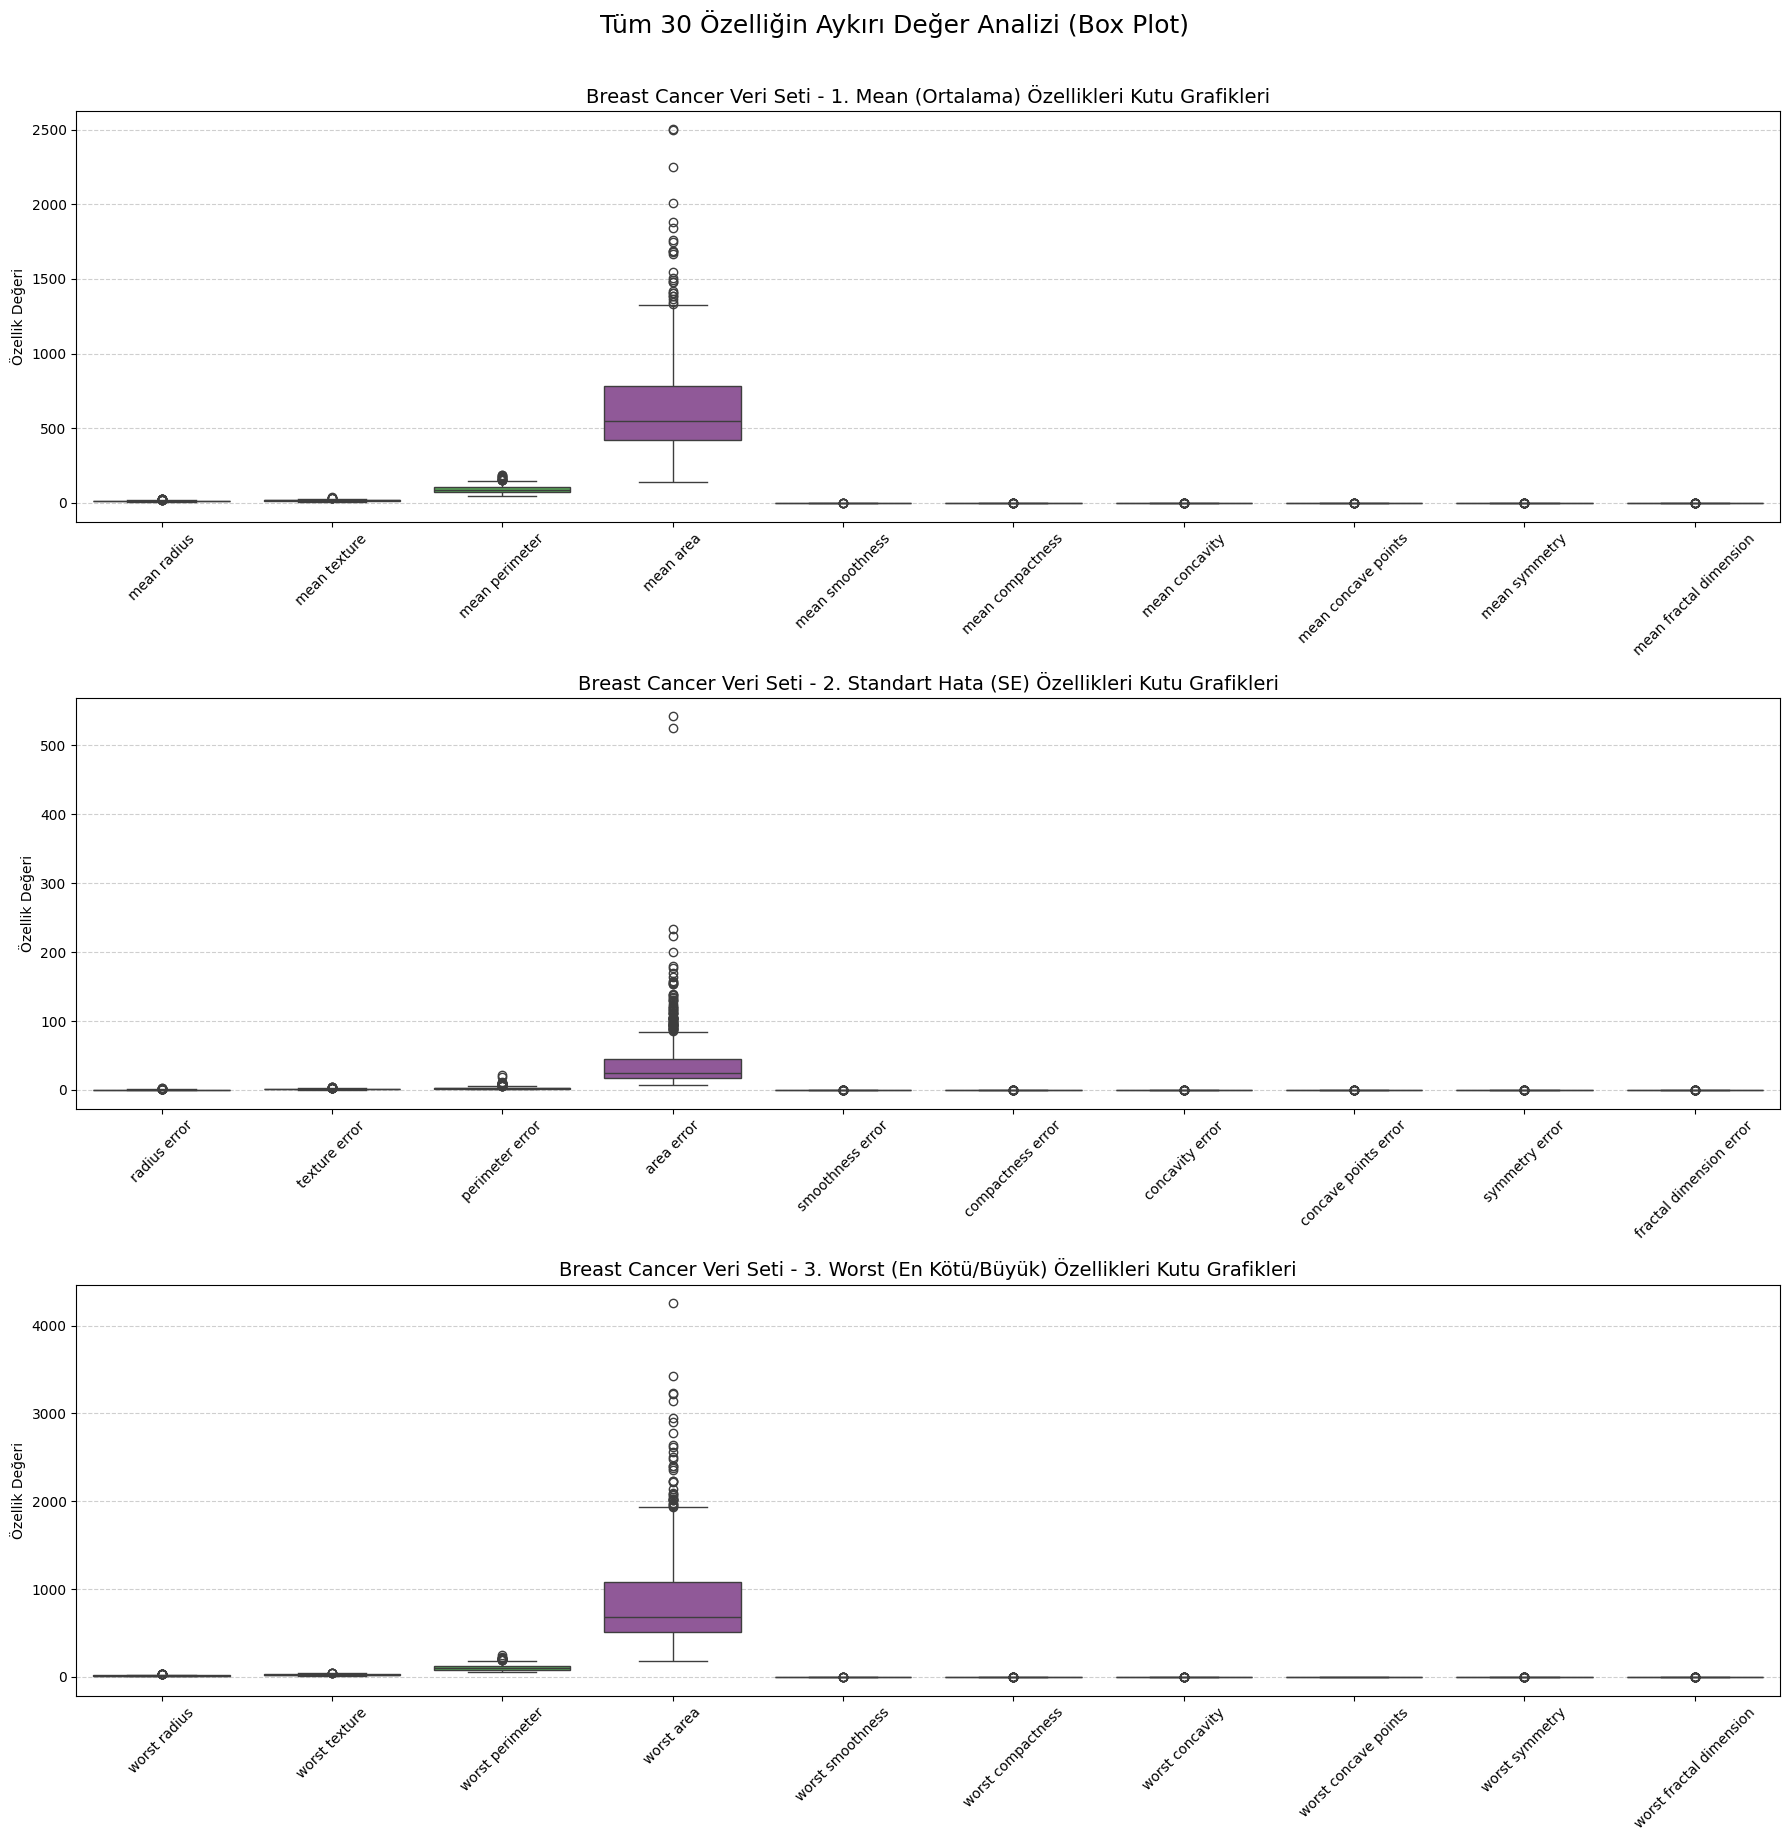

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


feature_groups = {
    '1. Mean (Ortalama) Özellikleri': X.columns[0:10],
    '2. Standart Hata (SE) Özellikleri': X.columns[10:20],
    '3. Worst (En Kötü/Büyük) Özellikleri': X.columns[20:30]
}

fig, axes = plt.subplots(3, 1, figsize=(18, 18))

for i, (title, cols) in enumerate(feature_groups.items()):
    sns.boxplot(data=X[cols], orient="v", palette="Set1", ax=axes[i])
    axes[i].set_title(f'Breast Cancer Veri Seti - {title} Kutu Grafikleri', fontsize=14)
    axes[i].set_ylabel('Özellik Değeri', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle('Tüm 30 Özelliğin Aykırı Değer Analizi (Box Plot)', fontsize=18, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 1.01])
plt.show()

**5. Veri Setinin Bölünmesi**

In [11]:
from sklearn.model_selection import train_test_split
import pandas as pd


X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.125,
    random_state=42,
    stratify=y_train_val
)


print("###  Veri Başarıyla 3 Kümeye Bölündü ###")
print(f"Eğitim Seti (X_train_final) Boyutu: {X_train_final.shape}")
print(f"Doğrulama Seti (X_val) Boyutu: {X_val.shape}")
print(f"Test Seti (X_test) Boyutu: {X_test.shape}")

###  Veri Başarıyla 3 Kümeye Bölündü ###
Eğitim Seti (X_train_final) Boyutu: (398, 30)
Doğrulama Seti (X_val) Boyutu: (57, 30)
Test Seti (X_test) Boyutu: (114, 30)


**4. Veri Ölçeklendirme (Scaling)**


In [12]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_final)


X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("### Veri  Ölçeklendirildi ###")
print("Eğitim Seti (Ölçeklendirilmiş) Ortalaması (İlk Kolon):", X_train_scaled.iloc[:, 0].mean().round(2))
print("Test Seti (Ölçeklendirilmiş) Ortalaması (İlk Kolon):", X_test_scaled.iloc[:, 0].mean().round(2))
print("\nÖrnek (X_train_scaled ilk 5 satır):")
print(X_train_scaled.head())

### Veri  Ölçeklendirildi ###
Eğitim Seti (Ölçeklendirilmiş) Ortalaması (İlk Kolon): -0.0
Test Seti (Ölçeklendirilmiş) Ortalaması (İlk Kolon): 0.07

Örnek (X_train_scaled ilk 5 satır):
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0    -0.464835      0.176821       -0.467521  -0.518737        -0.883771   
1    -1.084133     -1.553003       -1.065325  -0.944480         0.250510   
2    -0.715369     -0.014881       -0.721221  -0.693926        -0.814026   
3    -0.298750     -0.116370       -0.277754  -0.402988         0.855460   
4     1.024295      2.012644        1.033914   0.932543         0.251244   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0         -0.073305       -0.280632            -0.466742      -0.076775   
1         -0.553959       -0.868776            -0.752546      -0.009649   
2         -0.520657       -0.441841            -0.889004       0.806456   
3          0.463223        0.051734             0.166020  

**6. Farklı MLP Modellerinin Kurulması**

In [13]:
from sklearn.neural_network import MLPClassifier

models = {
    'Model 1 - Basit': MLPClassifier(
        hidden_layer_sizes=(16,),
        activation='relu',
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42,
        early_stopping=True
    ),
    'Model 2 - Orta': MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation='relu',
        learning_rate_init=0.005,
        max_iter=1000,
        random_state=42,
        early_stopping=True
    ),
    'Model 3 - Geniş': MLPClassifier(
        hidden_layer_sizes=(64, 64),
        activation='tanh',
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42,
        early_stopping=True
    ),
    'Model 4 - Derin': MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        learning_rate_init=0.0005,
        max_iter=1000,
        random_state=42,
        early_stopping=True
    ),
    'Model 5 - Düşük': MLPClassifier(
        hidden_layer_sizes=(32,),
        activation='relu',
        learning_rate_init=0.0001,
        max_iter=1000,
        random_state=42,
        early_stopping=True
    )
}


for name, model in models.items():
    print(f"\n{name}:")
    print(f"  • Hidden Layers: {model.hidden_layer_sizes}")
    print(f"  • Activation: {model.activation}")
    print(f"  • Learning Rate: {model.learning_rate_init}")




Model 1 - Basit:
  • Hidden Layers: (16,)
  • Activation: relu
  • Learning Rate: 0.001

Model 2 - Orta:
  • Hidden Layers: (32, 16)
  • Activation: relu
  • Learning Rate: 0.005

Model 3 - Geniş:
  • Hidden Layers: (64, 64)
  • Activation: tanh
  • Learning Rate: 0.001

Model 4 - Derin:
  • Hidden Layers: (128, 64, 32)
  • Activation: relu
  • Learning Rate: 0.0005

Model 5 - Düşük:
  • Hidden Layers: (32,)
  • Activation: relu
  • Learning Rate: 0.0001


**7. Validation Performanslarının Ölçülmesi**

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import time
import pandas as pd


results = []

print("###  Modeller Eğitiliyor ... ###")

for name, model in models.items():
    print(f"\n-> {name} Eğitimi Başlatıldı...")

    start_time = time.time()


    model.fit(X_train_scaled, y_train_final)

    end_time = time.time()
    train_time = end_time - start_time
    y_val_pred = model.predict(X_val_scaled)
    y_val_proba = model.predict_proba(X_val_scaled)[:, 1]

    # Metrikleri Hesaplama
    acc = accuracy_score(y_val, y_val_pred)
    prec = precision_score(y_val, y_val_pred, zero_division=0)
    rec = recall_score(y_val, y_val_pred, zero_division=0)
    f1 = f1_score(y_val, y_val_pred, zero_division=0)
    roc_auc = roc_auc_score(y_val, y_val_proba)

    # Sonuçları kaydetme
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "Eğitim Süresi (sn)": f"{train_time:.2f}"
    })

# Sonuç DataFrame'ini oluşturma ve ROC-AUC'a göre sıralama
validation_results_df = pd.DataFrame(results)
validation_results_df = validation_results_df.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)

print("\n###  Doğrulama Performansları Özeti (Validation Set) ###")
print(validation_results_df.to_string(index=False, float_format="%.4f"))

###  Modeller Eğitiliyor ... ###

-> Model 1 - Basit Eğitimi Başlatıldı...

-> Model 2 - Orta Eğitimi Başlatıldı...

-> Model 3 - Geniş Eğitimi Başlatıldı...

-> Model 4 - Derin Eğitimi Başlatıldı...

-> Model 5 - Düşük Eğitimi Başlatıldı...

###  Doğrulama Performansları Özeti (Validation Set) ###
          Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC Eğitim Süresi (sn)
Model 3 - Geniş    0.9649     0.9722  0.9722    0.9722   0.9907               2.51
 Model 2 - Orta    0.9474     0.9459  0.9722    0.9589   0.9881               0.06
Model 1 - Basit    0.8596     0.8182  1.0000    0.9000   0.9630               0.12
Model 4 - Derin    0.9474     0.9459  0.9722    0.9589   0.9577               0.90
Model 5 - Düşük    0.6491     0.6429  1.0000    0.7826   0.3413               0.03


**8. En İyi Modelin Test Üzerinde Değerlendirilmesi**

In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)


best_model = models["Model 4 - Derin"]
y_test_pred = best_model.predict(X_test_scaled)
y_test_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Metrikleri Hesaplama
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, zero_division=0)
test_rec = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
test_roc_auc = roc_auc_score(y_test, y_test_proba)

print("###  Model 4 (Derin) - Test Seti Performans Metrikleri ###")
print(f"Accuracy: {test_acc:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall: {test_rec:.4f}")
print(f"F1-Score: {test_f1:.4f}")
print(f"ROC-AUC: {test_roc_auc:.4f}")

print("\nDetaylı Sınıflandırma Raporu:")
print(classification_report(y_test, y_test_pred))

###  Model 4 (Derin) - Test Seti Performans Metrikleri ###
Accuracy: 0.8860
Precision: 0.9538
Recall: 0.8611
F1-Score: 0.9051
ROC-AUC: 0.9798

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.80      0.93      0.86        42
           1       0.95      0.86      0.91        72

    accuracy                           0.89       114
   macro avg       0.87      0.89      0.88       114
weighted avg       0.90      0.89      0.89       114



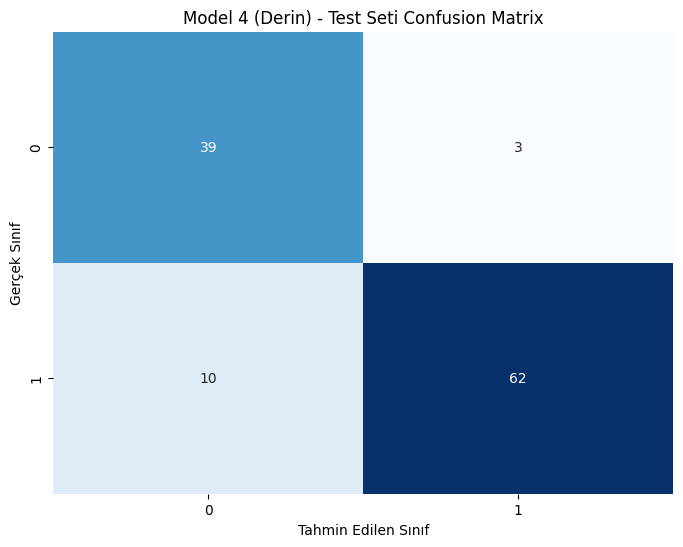

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=best_model.classes_,
    yticklabels=best_model.classes_
)
plt.title('Model 4 (Derin) - Test Seti Confusion Matrix', fontsize=12)
plt.ylabel('Gerçek Sınıf', fontsize=10)
plt.xlabel('Tahmin Edilen Sınıf', fontsize=10)
plt.show()

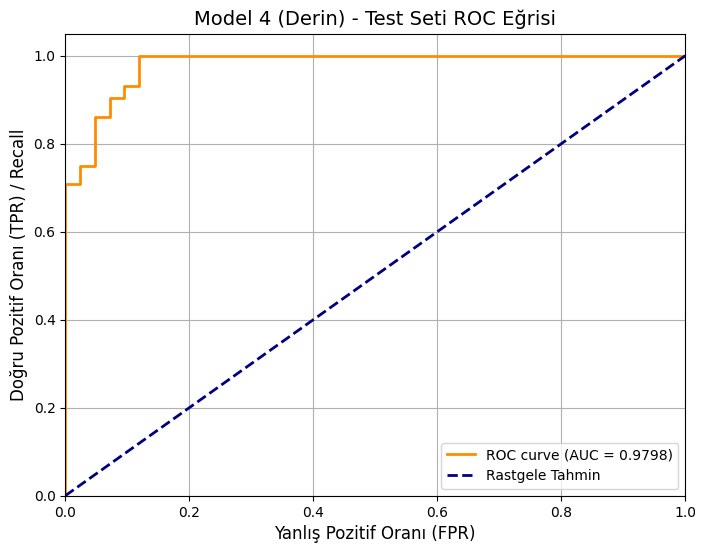

In [17]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ROC verilerini hesaplama
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Rastgele Tahmin')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Yanlış Pozitif Oranı (FPR)', fontsize=12)
plt.ylabel('Doğru Pozitif Oranı (TPR) / Recall', fontsize=12)
plt.title('Model 4 (Derin) - Test Seti ROC Eğrisi', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


**9. Optuna ile Hiperparametre Optimizasyonu (150 Deneme)**


In [19]:
!pip install optuna
import optuna
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import numpy as np



def objective(trial):
    # 9.2 Optuna Arama Aralıklarından Parametre Seçimi


    layer1_size = trial.suggest_int("layer1_size", 16, 256)
    layer2_size = trial.suggest_int("layer2_size", 8, 128)
    hidden_layer_sizes = (layer1_size, layer2_size);

    # Learning Rate ve Alpha (L2 Regularization)
    learning_rate_init = trial.suggest_loguniform("learning_rate_init", 1e-5, 1e-1)
    alpha = trial.suggest_loguniform("alpha", 1e-6, 1e-2);

    # Kategorik Parametreler
    activation = trial.suggest_categorical("activation", ["relu", "tanh"])
    solver = trial.suggest_categorical("solver", ["adam", "sgd"])
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128]);

    # 9.3 Eğitim Döngüsü

    # Modeli tanımlama
    mlp = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation=activation,
        solver=solver,
        alpha=alpha,
        learning_rate_init=learning_rate_init,
        batch_size=batch_size,
        max_iter=500,           # Sabit iterasyon
        random_state=42,        # Tekrarlanabilirlik
    )

    # Modeli eğitim seti üzerinde eğitme (fit)
    try:
        mlp.fit(X_train_scaled, y_train_final)
    except Exception as e:
        # Hata durumunda (Örn: SGD ile yakınsayamama) düşük bir değer döndür
        return 0.0

    # Doğrulama setinde tahmin yapma
    y_val_pred = mlp.predict(X_val_scaled)

    # Metrik: Accuracy'yi hesaplama
    accuracy = accuracy_score(y_val, y_val_pred)

    return accuracy

# Optuna Study'yi oluşturma
study = optuna.create_study(direction="maximize", study_name="MLP_HPO_Study")

# Optimizasyonu başlatma
print("###  Optuna Hiperparametre Optimizasyonu Başlatılıyor (150 Deneme) ###")
study.optimize(objective, n_trials=150, show_progress_bar=True)
print("Optimizasyon Tamamlandı.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 11.8 MB/s eta 0:00:00


[I 2025-11-28 08:25:50,515] A new study created in memory with name: MLP_HPO_Study


###  Optuna Hiperparametre Optimizasyonu Başlatılıyor (150 Deneme) ###


  0%|          | 0/150 [00:00<?, ?it/s]

/tmp/ipython-input-1869136285.py:18: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate_init = trial.suggest_loguniform("learning_rate_init", 1e-5, 1e-1)
/tmp/ipython-input-1869136285.py:19: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform("alpha", 1e-6, 1e-2);


...

[I 2025-11-28 08:30:58,043] Trial 147 finished with value: 0.9824561403508771 and parameters: {'layer1_size': 16, 'layer2_size': 12, 'learning_rate_init': 0.01948637170687003, 'alpha': 2.1565232612962112e-06, 'activation': 'tanh', 'solver': 'sgd', 'batch_size': 128}. Best is trial 5 with value: 0.9824561403508771.


/tmp/ipython-input-1869136285.py:18: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate_init = trial.suggest_loguniform("learning_rate_init", 1e-5, 1e-1)
/tmp/ipython-input-1869136285.py:19: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform("alpha", 1e-6, 1e-2);


[I 2025-11-28 08:30:59,622] Trial 148 finished with value: 0.9649122807017544 and parameters: {'layer1_size': 120, 'layer2_size': 23, 'learning_rate_init': 0.025830933023580433, 'alpha': 3.862815099097821e-05, 'activation': 'tanh', 'solver': 'sgd', 'batch_size': 32}. Best is trial 5 with value: 0.9824561403508771.


/tmp/ipython-input-1869136285.py:18: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate_init = trial.suggest_loguniform("learning_rate_init", 1e-5, 1e-1)
/tmp/ipython-input-1869136285.py:19: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform("alpha", 1e-6, 1e-2);


[I 2025-11-28 08:31:00,754] Trial 149 finished with value: 0.9649122807017544 and parameters: {'layer1_size': 75, 'layer2_size': 16, 'learning_rate_init': 0.017263232297015076, 'alpha': 0.005674100044738124, 'activation': 'tanh', 'solver': 'sgd', 'batch_size': 128}. Best is trial 5 with value: 0.9824561403508771.
Optimizasyon Tamamlandı.


In [ ]:
from sklearn.metrics import f1_score, roc_auc_score

best_trial = study.best_trial

best_params = best_trial.params
best_hidden_layers = (best_params.pop('layer1_size'), best_params.pop('layer2_size'))

# En iyi modeli kurma
best_mlp = MLPClassifier(
    hidden_layer_sizes=best_hidden_layers,
    activation=best_params['activation'],
    solver=best_params['solver'],
    alpha=best_params['alpha'],
    learning_rate_init=best_params['learning_rate_init'],
    batch_size=best_params['batch_size'],
    max_iter=500,
    random_state=42
)

# En iyi modeli eğitme
best_mlp.fit(X_train_scaled, y_train_final)

y_val_pred = best_mlp.predict(X_val_scaled)
y_val_proba = best_mlp.predict_proba(X_val_scaled)[:, 1]

final_acc = accuracy_score(y_val, y_val_pred)
final_f1 = f1_score(y_val, y_val_pred, zero_division=0)
final_roc_auc = roc_auc_score(y_val, y_val_proba)

print("\n###  Optuna En İyi Model Raporu ###")


print(f"En İyi Doğruluk (Validation Accuracy): {best_trial.value:.4f}")
print("\nEn İyi Hiperparametreler:")


print(f"  hidden_layer_sizes: {best_hidden_layers}")
for key, value in best_params.items():
    print(f"  {key}: {value}")

print("\nDoğrulama Seti Üzerinde Tüm Metrikler:")
print(f"  Accuracy: {final_acc:.4f}")
print(f"  F1-Score: {final_f1:.4f}")
print(f"  ROC-AUC: {final_roc_auc:.4f}")

In [ ]:
!pip install shap
import shap
import numpy as np


explainer = shap.Explainer(
    best_mlp.predict_proba,
    X_train_scaled.sample(n=100, random_state=42)
)


print("SHAP değerleri hesaplanıyor... (Bu işlem birkaç dakika sürebilir)")
shap_values = explainer(X_test_scaled)

In [ ]:
import matplotlib.pyplot as plt
import shap
import numpy as np

print("### ƒ̈ 1. SHAP Summary Plot (Tüm Veri Küresel Önemi) ###")


shap.summary_plot(
    shap_values[:, :, 1],
    X_test_scaled,
    show=False
)

plt.title('SHAP Summary Plot - Özelliklerin Tahmine Etkisi (İyi Huylu)', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
print("\n### 2. SHAP Bar Plot (Ortalama Etki Büyüklüğü) ###")

# SHAP değerlerinin ortalama mutlak büyüklüğünü görselleştirme (Sınıf 1 - İyi Huylu için)
plt.figure(figsize=(10, 7))
shap.plots.bar(
    shap_values[:, :, 1].abs.mean(0), # Mutlak ortalama SHAP değeri
    show=False
)
plt.title('SHAP Bar Plot - Özellik Önem Sıralaması', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
print("\n###  3. SHAP Force Plot (Tek Örnek Açıklaması) ###")

example_index = 5

shap.plots.force(
    shap_values[example_index, :, 1],
    matplotlib=True,
    show=False
)
plt.title(f'SHAP Force Plot - Örnek {example_index}', fontsize=14)
plt.show()

In [ ]:


plt.figure(figsize=(10, 10))
if isinstance(shap_values_optuna, list):
    shap.decision_plot(
        explainer_optuna.expected_value[1],
        shap_values_optuna[1][:20],
        X_val.iloc[:20],
        show=False
    )
else:
    shap.decision_plot(
        explainer_optuna.expected_value[1],
        shap_values_optuna[:20, :, 1],
        X_val.iloc[:20],
        show=False
    )

plt.title('SHAP Decision Plot - İlk 20 Örnek', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


print("Decision Plot: Her bir özelliğin tahmine katkısını base value'dan başlayarak gösterir.")
print("Her çizgi bir gözlemi temsil eder ve özellikler boyunca nasıl karar verildiğini gösterir.")



**SHAP Karşılaştırmalı Analiz**

In [ ]:


# Optuna model için en önemli özellikleri hesapla
if isinstance(shap_values_optuna, list):
    mean_abs_shap_optuna = np.abs(shap_values_optuna[1]).mean(axis=0)
else:
    mean_abs_shap_optuna = np.abs(shap_values_optuna[:, :, 1]).mean(axis=0)

feature_importance_optuna = pd.DataFrame({
    'Feature': X_val.columns,
    'Importance': mean_abs_shap_optuna
}).sort_values('Importance', ascending=False)

print("\nOPTUNA EN İYİ MODEL - En Baskın 10 Özellik:")
display(feature_importance_optuna.head(10))


print("\nKARARI BELİRLEYEN ÖZELİKLER")
print("-" * 70)
print(f"Optuna modelinde en etkili özellik: {feature_importance_optuna.iloc[0]['Feature']}")
print(f"  SHAP importance değeri: {feature_importance_optuna.iloc[0]['Importance']:.4f}")
print(f"\nİkinci en etkili: {feature_importance_optuna.iloc[1]['Feature']}")
print(f"  SHAP importance değeri: {feature_importance_optuna.iloc[1]['Importance']:.4f}")
print(f"\nÜçüncü en etkili: {feature_importance_optuna.iloc[2]['Feature']}")
print(f"  SHAP importance değeri: {feature_importance_optuna.iloc[2]['Importance']:.4f}")

print("\nBu özellikler:")
print("  • Modelin tahmin yaparken en çok güvendiği bilgilerdir")
print("  • Yüksek SHAP değerleri, bu özelliklerin çıktı üzerinde büyük etkisi olduğunu gösterir")
print("  • Breast cancer verisinde bu özellikler tümör karakteristiklerini en iyi ayırt eder")

